In [37]:
import tensorflow as tf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
np.set_printoptions(threshold=np.inf)


In [38]:
df=pd.read_csv("../DataFrames/NYC_Central_Park_weather_1869-2022.csv")
df['DATE']=pd.to_datetime(df['DATE'])
df["DATE"] = df["DATE"].dt.strftime("%m-%d-%Y")
df['DATE']=pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)



In [39]:
df['Temp']=(df["TMAX"]+df['TMIN'])/2
temp=df['Temp']
#print(temp.isna().sum())
temp = temp.ffill()
#print(temp.isna().sum())
#print(temp.head())
#temp.plot(figsize=(18, 6))
#print(temp[-60:])

In [40]:
def df_to_array(df, window_size):
    df_as_np=df.to_numpy()
    #print(df_as_np)
    X=[]
    y=[]
    for i in range(len(df_as_np)-window_size):
        row=[[a] for a in df_as_np[i:i+window_size]]
        X.append(row)
        label=df_as_np[i+window_size]
        y.append(label)
    return np.array(X), np.array(y)

WINDOW_SIZE=60
X, y =df_to_array(temp, WINDOW_SIZE)
X.shape, y.shape


((56185, 60, 1), (56185,))

In [41]:
X_train, y_train=X[:46000], y[:46000]
X_val, y_val=X[46000:51150], y[46000:51150]
X_test, y_test=X[51150:], y[51150:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape


((46000, 60, 1), (46000,), (5150, 60, 1), (5150,), (5035, 60, 1), (5035,))

In [42]:
from tensorflow.keras.models import Sequential              #to
from tensorflow.keras.layers import *                       #to 
from tensorflow.keras.callbacks import ModelCheckpoint      #to save the model that does best on validations
from tensorflow.keras.losses import MeanSquaredError        # to 
from tensorflow.keras.metrics import RootMeanSquaredError   # sqrt of the errror
from tensorflow.keras.optimizers import Adam

In [43]:
model1=Sequential()                                 #Creates a neural network 
model1.add(InputLayer((WINDOW_SIZE, 1)))            #Tells the models teh shape on one training example
model1.add(LSTM(64))                                
model1.add(Dense(8, 'relu'))
model1.add(Dense(1, 'linear'))
model1.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,425 (68.07 KB)

 Trainable params: 17,425 (68.07 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
cp=ModelCheckpoint('model1.keras', save_best_only=True)
model1.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.0001), metrics=[RootMeanSquaredError()])

In [45]:
model1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, callbacks=[cp])

Epoch 1/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - loss: 1719.8669 - root_mean_squared_error: 41.4713 - val_loss: 798.7881 - val_root_mean_squared_error: 28.2628
Epoch 2/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - loss: 412.1064 - root_mean_squared_error: 20.3004 - val_loss: 188.5087 - val_root_mean_squared_error: 13.7298
Epoch 3/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - loss: 96.1195 - root_mean_squared_error: 9.8041 - val_loss: 51.3243 - val_root_mean_squared_error: 7.1641
Epoch 4/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 39.2082 - root_mean_squared_error: 6.2616 - val_loss: 32.6804 - val_root_mean_squared_error: 5.7167
Epoch 5/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 32.0299 - root_mean_squared_error: 5.6595 - val_loss: 29.3184 - val_root_mean_squared_error: 5.4146
Epoch 6/30
1438/1438 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 30.5201 - root_mean_squared_error: 5.5245 - val_loss: 28.3748 - val_root_mean_squared_error: 5.3268
Epoch 7

In [46]:
from tensorflow.keras.models import load_model
model1=load_model('model1.keras')

In [47]:
train_predicions=model1.predict(X_train).flatten()
train_results=pd.DataFrame(data={'Train Predictions': train_predicions, 'Actuals': y_train})
train_results

1438/1438 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step


,Train Predictions,Actuals
0,20.611589,27.5
1,33.515507,35.5
2,34.542789,31.5
3,30.281504,23.0
4,24.170567,28.0
...,...,...
45995,34.657047,18.0
45996,17.555218,13.0
45997,21.409334,20.0
45998,25.802391,23.0


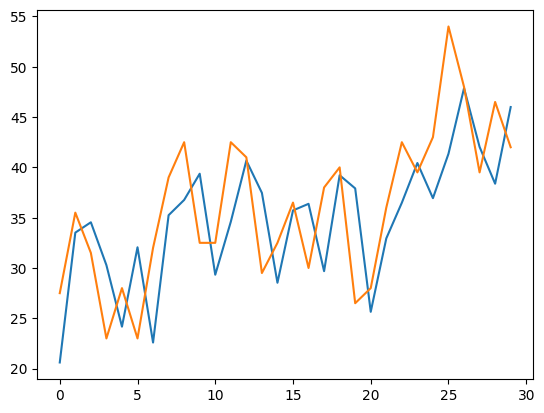

In [48]:
plt.plot(train_results["Train Predictions"][:30], label='Train Predictions')
plt.plot(train_results["Actuals"][:30], label='Real Data')


In [49]:
val_predicions=model1.predict(X_val).flatten()
val_results=pd.DataFrame(data={'Validation Predictions': val_predicions, 'Actuals': y_val})
val_results


161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Validation Predictions,Actuals
0,25.391529,33.5
1,34.977543,38.0
2,35.175858,19.5
3,16.557020,20.0
4,26.914040,27.0
...,...,...
5145,36.411972,33.5
5146,37.592373,41.5
5147,43.570072,46.5
5148,45.565128,43.5


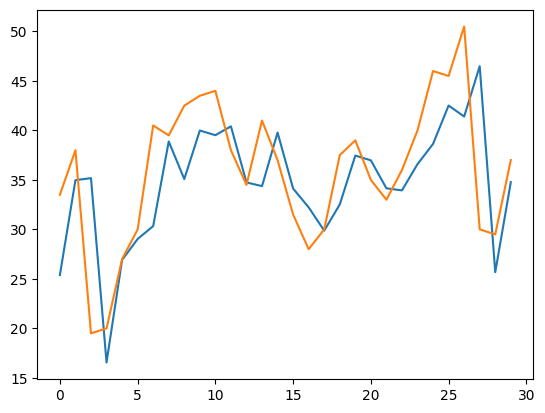

In [50]:
plt.plot(val_results["Validation Predictions"][:30], label='Validation Predictions')
plt.plot(val_results["Actuals"][:30], label="Real Data")

In [51]:
test_predictions=model1.predict(X_test).flatten()
test_results=pd.DataFrame(data={'Test Predictions': test_predictions, 'Actuals': y_test})
test_results


158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


,Test Predictions,Actuals
0,45.721134,52.5
1,50.292778,47.5
2,45.304859,39.5
3,40.755547,40.0
4,42.951817,44.5
...,...,...
5030,15.169527,21.0
5031,30.658432,23.5
5032,25.220655,32.0
5033,35.561100,40.0


Text(0.5, 1.0, '2022 Test Predictions vs Real Data')

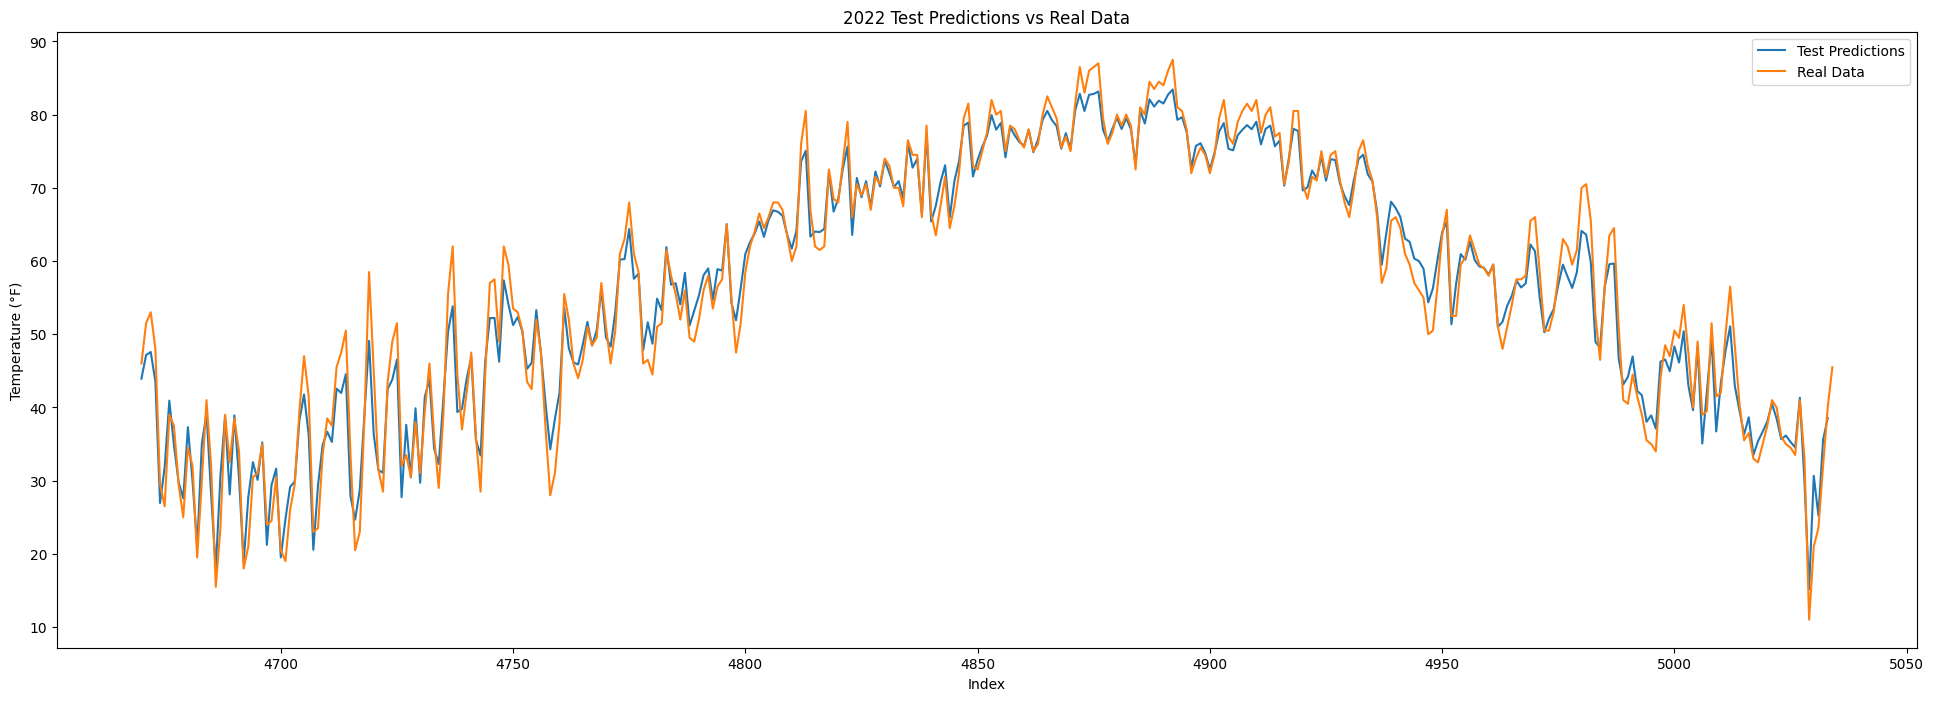

In [52]:
plt.figure(figsize=(24, 8))
preds = pd.Series(test_results["Test Predictions"][-365:]).shift(-1)
plt.plot(preds, label='Test Predictions')
plt.plot(test_results["Actuals"][-365:], label='Real Data')
plt.legend()
plt.xlabel("Index")
plt.ylabel('Temperature (\u00B0F)')
plt.title('2022 Test Predictions vs Real Data')


Average Error:  -0.2780934853728975


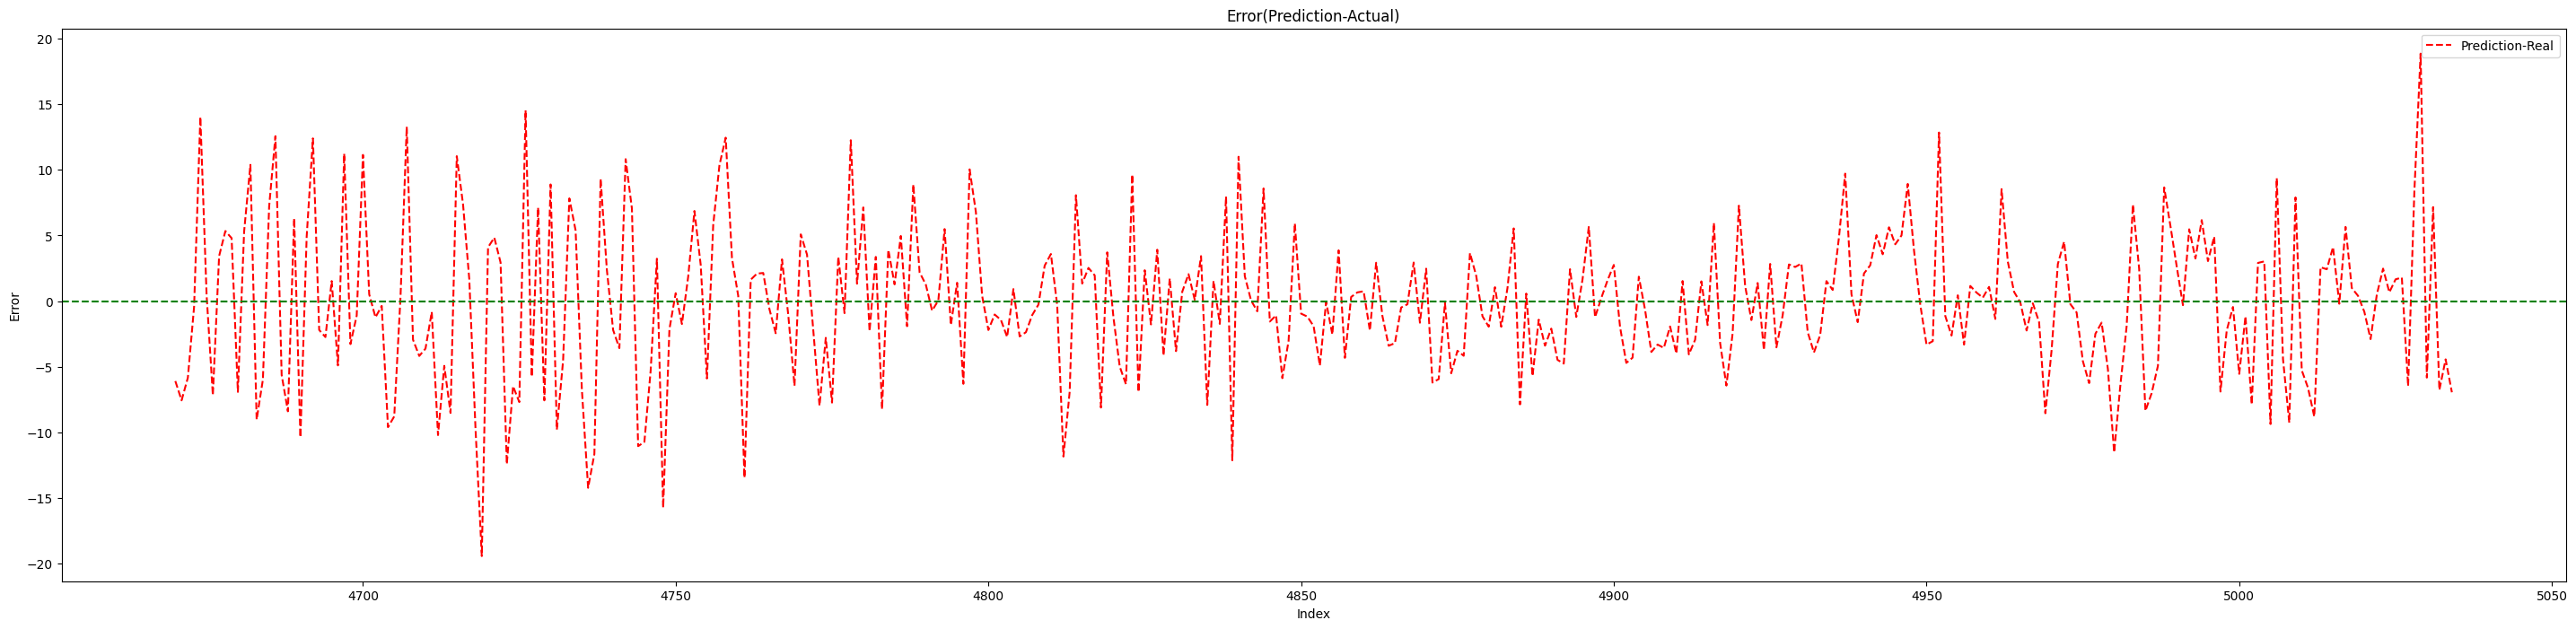

In [53]:
errors=test_results['Test Predictions']-test_results['Actuals']
#print(errors[:20])
avg_error=np.mean(errors)
print("Average Error: ", avg_error)
plt.figure(figsize=(36, 8))
plt.plot(errors[-365:], linestyle='dashed', color='red', label='Prediction-Real')
plt.axhline(0, linestyle='--', color='green')
plt.xlabel('Index')
plt.ylabel('Error')
plt.title('Error(Prediction-Actual)')
plt.legend()

In [54]:
next_100_years=pd.date_range(
    start="01-01-2023",
    periods=36500,
    freq='D'
)
print(next_100_years)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2122-11-28', '2122-11-29', '2122-11-30', '2122-12-01',
               '2122-12-02', '2122-12-03', '2122-12-04', '2122-12-05',
               '2122-12-06', '2122-12-07'],
              dtype='datetime64[us]', length=36500, freq='D')


In [55]:
future_predictions=temp.values[-60:].tolist()
for i in range(365):
    currentWindow=np.array([[[a] for a in future_predictions[-WINDOW_SIZE:]]])
    prediction=model1.predict(currentWindow, verbose=0)
    future_predictions.append(prediction[0][0])


56245
425
-55820
[37.68487549 36.15150452 35.60150528 35.29705429 35.06805801 34.87736511
 34.7192955  34.59076309 34.48418427 34.39453125 34.3291893  34.29650116
 34.28264236 34.26915359 34.25201035 34.23552322 34.21878433 34.20090866
 34.18206787 34.15731812 34.11748123 34.07320023 34.04441071 34.03356171
 34.036026   34.04933929 34.06580734 34.07390594 34.07075882 34.0641861
 34.06025314 34.05788422 34.05392838 34.04730225 34.03816605 34.0213356
 34.05485916 34.24401474 34.53524017 34.82152176 35.04870224 35.17935562
 35.16702271 35.07045746 35.03738403 35.17860031 35.46945572 35.79528046
 36.08246231 36.3264122  36.72264481 37.39147949 38.06698608 38.52480316
 38.42007446 37.65351486 36.67153168 36.08670807 36.03115463 36.30244827
 36.64100266 36.91809845 37.13642502 37.32866287 37.51342392 37.69761658
 37.88366318 38.07261276 38.2649231  38.4606781  38.66012955 38.86432648
 39.07489014 39.29317474 39.51999283 39.75590515 40.00146866 40.25731277
 40.52410507 40.80223465 41.09140778

Text(0.5, 1.0, '365 Day Forecast')

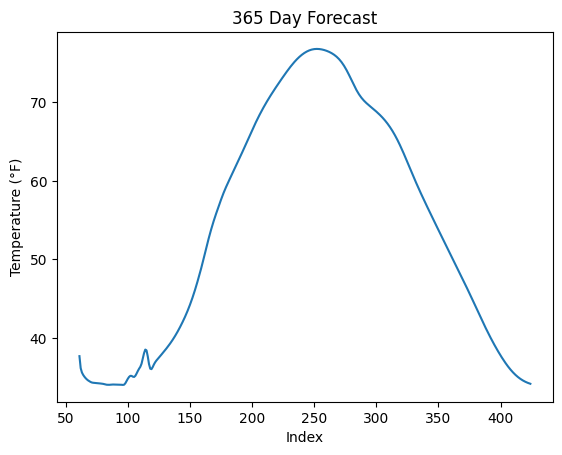

In [56]:
print(len(temp))
print(len(future_predictions))
print(len(future_predictions)-len(temp))

future_predictions = np.array(future_predictions).reshape(-1)
new_Year=pd.DataFrame({'values': future_predictions})
plt.plot(new_Year['values'][61:])
print(future_predictions[61:])
plt.xlabel('Index')
plt.ylabel('Temperature (\u00B0F)')
plt.title('365 Day Forecast')

[37.68487549 36.15150452 35.60150528 35.29705429 35.06805801 34.87736511
 34.7192955  34.59076309 34.48418427 34.39453125 34.3291893  34.29650116
 34.28264236 34.26915359 34.25201035 34.23552322 34.21878433 34.20090866
 34.18206787 34.15731812 34.11748123 34.07320023 34.04441071 34.03356171
 34.036026   34.04933929 34.06580734 34.07390594 34.07075882 34.0641861
 34.06025314 34.05788422 34.05392838 34.04730225 34.03816605 34.0213356
 34.05485916 34.24401474 34.53524017 34.82152176 35.04870224 35.17935562
 35.16702271 35.07045746 35.03738403 35.17860031 35.46945572 35.79528046
 36.08246231 36.3264122  36.72264481 37.39147949 38.06698608 38.52480316
 38.42007446 37.65351486 36.67153168 36.08670807 36.03115463 36.30244827
 36.64100266 36.91809845 37.13642502 37.32866287 37.51342392 37.69761658
 37.88366318 38.07261276 38.2649231  38.4606781  38.66012955 38.86432648
 39.07489014 39.29317474 39.51999283 39.75590515 40.00146866 40.25731277
 40.52410507 40.80223465 41.09140778 41.39091492 41.7

Text(0.5, 1.0, '365 Day Forecast')

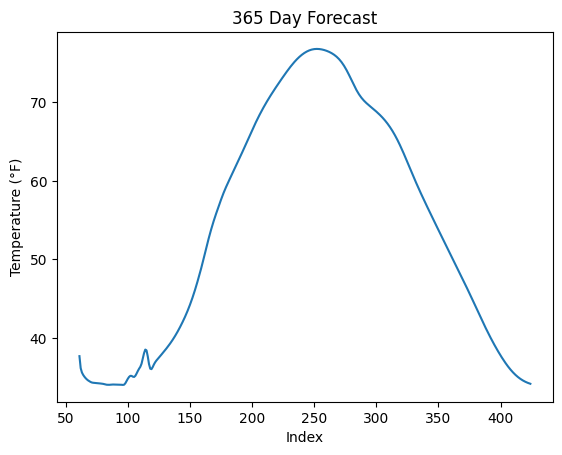

In [57]:

plt.plot(new_Year['values'][61:])
print(future_predictions[61:])
plt.xlabel('Index')
plt.ylabel('Temperature (\u00B0F)')
plt.title('365 Day Forecast')

In [58]:
mae=mean_absolute_error(y_test.flatten(), test_predictions.flatten())
print("Mean Absolute Error= ", mae)

Mean Absolute Error=  4.0965761929069755
